# Custom CNN Model Trained from Scratch for Error Classification

This notebook implements a custom Convolutional Neural Network trained from scratch to classify different types of application errors.

## 1. Import Libraries

In [1]:
# Ensure required packages are installed in the active notebook environment.
import importlib
import subprocess
import sys


def ensure_package(package_name, import_name=None):
    module_name = import_name or package_name
    try:
        importlib.import_module(module_name)
        print(f"OK: {package_name} already installed")
    except ModuleNotFoundError:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])


ensure_package("torch")
ensure_package("torchvision")
ensure_package("scikit-learn", "sklearn")
ensure_package("seaborn")

OK: torch already installed
OK: torchvision already installed
OK: scikit-learn already installed
OK: seaborn already installed


In [2]:
import json
import random
from collections import Counter
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings("ignore")

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

PyTorch version: 2.11.0+cpu
Device: cpu


In [3]:
# Build a recursive image index using only the top-level folder as the class label.
IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.bmp', '.gif', '.webp')

def collect_class_samples(root_dir):
    root_path = Path(root_dir)
    class_names = sorted([item.name for item in root_path.iterdir() if item.is_dir()])
    samples = []
    image_counts = {}

    for class_idx, class_name in enumerate(class_names):
        class_dir = root_path / class_name
        class_images = sorted(
            path for path in class_dir.rglob('*')
            if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
        )
        image_counts[class_name] = len(class_images)
        samples.extend((str(path), class_idx) for path in class_images)

    return class_names, samples, image_counts


class PathImageDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None, minority_labels=None, minority_transform=None):
        self.image_paths = list(image_paths)
        self.labels = list(labels)
        self.transform = transform
        self.minority_labels = set(minority_labels or [])
        self.minority_transform = minority_transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        import PIL
        image_path = self.image_paths[idx]
        label = self.labels[idx]
        image = PIL.Image.open(image_path).convert('RGB')

        if self.minority_transform is not None and label in self.minority_labels:
            image = self.minority_transform(image)
        elif self.transform is not None:
            image = self.transform(image)

        return image, label

## 2. Data Exploration

In [4]:
# Define the dataset folder using a workspace-relative path
ROOT = Path('..').resolve().parent  # notebook is in TFM/Model_Notebooks
DATA_DIR = ROOT / 'Data'

# Recursively collect all samples from the full Data folder
class_names, all_samples, all_image_counts = collect_class_samples(DATA_DIR)
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

# Create a stratified 80/20 split from the full dataset
all_paths = [path for path, _ in all_samples]
all_labels = np.array([label for _, label in all_samples], dtype=np.int64)
train_paths, val_paths, train_targets, val_targets = train_test_split(
    all_paths,
    all_labels,
    test_size=0.2,
    random_state=SEED,
    stratify=all_labels,
)

train_paths = list(train_paths)
val_paths = list(val_paths)
train_targets = np.array(train_targets, dtype=np.int64)
val_targets = np.array(val_targets, dtype=np.int64)

# Keep names used later in the notebook
sample_paths = train_paths
sample_labels = train_targets
val_sample_paths = val_paths
val_sample_labels = val_targets
num_classes = len(class_names)

train_class_counts = Counter(sample_labels.tolist())
val_class_counts = Counter(val_sample_labels.tolist())
train_image_counts = {class_names[idx]: train_class_counts.get(idx, 0) for idx in range(num_classes)}
val_image_counts = {class_names[idx]: val_class_counts.get(idx, 0) for idx in range(num_classes)}

print(f"Top-level class labels: {class_names}")
print(f"Number of classes: {num_classes}")
print("\nData image counts by class:")
for class_name in class_names:
    print(f"{class_name}: {all_image_counts[class_name]} images")

print("\nTraining image counts by class (80% split):")
for class_name in class_names:
    print(f"{class_name}: {train_image_counts[class_name]} images")

print("\nValidation image counts by class (20% split):")
for class_name in class_names:
    print(f"{class_name}: {val_image_counts[class_name]} images")

total_data_images = len(all_paths)
total_train_images = len(sample_paths)
total_val_images = len(val_sample_paths)
print(f"\nTotal images in Data: {total_data_images}")
print(f"Total training images: {total_train_images}")
print(f"Total validation images: {total_val_images}")

summary_df = pd.DataFrame({
    'Category': class_names,
    'Data Image Count': [all_image_counts[name] for name in class_names],
    'Train Image Count': [train_image_counts[name] for name in class_names],
    'Val Image Count': [val_image_counts[name] for name in class_names],
    'Train Percentage': [f"{100 * train_image_counts[name] / max(total_train_images, 1):.1f}%" for name in class_names],
    'Val Percentage': [f"{100 * val_image_counts[name] / max(total_val_images, 1):.1f}%" for name in class_names],
})
print("\nData Summary:")
print(summary_df)

Top-level class labels: ['Banner aplicación', 'Cierre aplicación', 'Error aplicativo', 'Error funcional', 'Error terminal', 'Indeterminado', 'Revisión circuito', 'Timeout']
Number of classes: 8

Data image counts by class:
Banner aplicación: 134 images
Cierre aplicación: 271 images
Error aplicativo: 361 images
Error funcional: 515 images
Error terminal: 589 images
Indeterminado: 29 images
Revisión circuito: 2168 images
Timeout: 302 images

Training image counts by class (80% split):
Banner aplicación: 107 images
Cierre aplicación: 217 images
Error aplicativo: 289 images
Error funcional: 412 images
Error terminal: 471 images
Indeterminado: 23 images
Revisión circuito: 1734 images
Timeout: 242 images

Validation image counts by class (20% split):
Banner aplicación: 27 images
Cierre aplicación: 54 images
Error aplicativo: 72 images
Error funcional: 103 images
Error terminal: 118 images
Indeterminado: 6 images
Revisión circuito: 434 images
Timeout: 60 images

Total images in Data: 4369
Tot

In [5]:
# Check class imbalance on train/validation folders
count_df = pd.DataFrame({
    'Category': class_names,
    'Train Count': [train_image_counts[name] for name in class_names],
    'Validation Count': [val_image_counts[name] for name in class_names],
})
count_df['Train Share'] = count_df['Train Count'] / max(count_df['Train Count'].sum(), 1)
count_df['Validation Share'] = count_df['Validation Count'] / max(count_df['Validation Count'].sum(), 1)
count_df['Train Imbalance vs. largest'] = count_df['Train Count'] / max(count_df['Train Count'].max(), 1)

print(count_df.sort_values('Train Count', ascending=False).to_string(index=False))
print(f"\nTotal training images: {count_df['Train Count'].sum()}")
print(f"Total validation images: {count_df['Validation Count'].sum()}")
print(f"Largest train class: {count_df.loc[count_df['Train Count'].idxmax(), 'Category']}")
print(f"Smallest train class: {count_df.loc[count_df['Train Count'].idxmin(), 'Category']}")

         Category  Train Count  Validation Count  Train Share  Validation Share  Train Imbalance vs. largest
Revisión circuito         1180               988     0.426918          0.615576                     1.000000
  Error funcional          493                22     0.178365          0.013707                     0.417797
   Error terminal          404               185     0.146165          0.115265                     0.342373
 Error aplicativo          219               142     0.079233          0.088474                     0.185593
          Timeout          194               108     0.070188          0.067290                     0.164407
Cierre aplicación          156               115     0.056440          0.071651                     0.132203
Banner aplicación          100                34     0.036179          0.021184                     0.084746
    Indeterminado           18                11     0.006512          0.006854                     0.015254

Total training ima

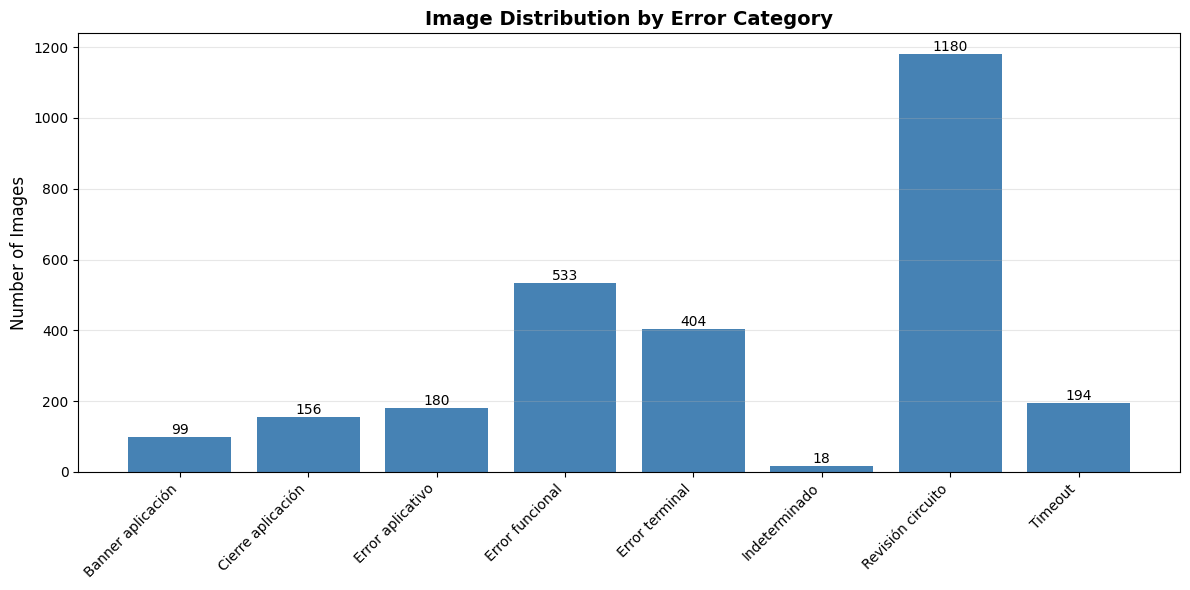


Data Summary:
            Category  Image Count Percentage
0  Banner aplicación           99       3.6%
1  Cierre aplicación          156       5.6%
2   Error aplicativo          180       6.5%
3    Error funcional          533      19.3%
4     Error terminal          404      14.6%
5      Indeterminado           18       0.7%
6  Revisión circuito         1180      42.7%
7            Timeout          194       7.0%


In [ ]:
# Visualize training data distribution
fig, ax = plt.subplots(figsize=(12, 6))
categories = list(train_image_counts.keys())
counts = list(train_image_counts.values())

bars = ax.bar(range(len(categories)), counts, color='steelblue')
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Training Image Distribution by Error Category (Data)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Create summary dataframe
summary_df = pd.DataFrame({
    'Category': categories,
    'Train Image Count': counts,
    'Train Percentage': [f"{100*count/max(total_train_images, 1):.1f}%" for count in counts]
})
print("\nTraining Data Summary:")
print(summary_df)

## 3. Data Preparation

In [6]:
# Define hyperparameters
IMAGE_SIZE = (224, 224)  # Standard image size for the CNN
BATCH_SIZE = 32
NUM_WORKERS = 0
BORDER_CROP = 120  # Crop pixels from top/bottom (mobile border effect)

print(f"Image Size: {IMAGE_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Border Crop: {BORDER_CROP} pixels")

Image Size: (224, 224)
Batch Size: 32
Border Crop: 120 pixels


In [7]:
# Build transforms with crop, resize, and mild non-rotational augmentation
def safe_mobile_border_crop(img):
    crop_margin = min(BORDER_CROP, max((img.height - 1) // 2, 0))
    return img.crop((0, crop_margin, img.width, img.height - crop_margin))

base_train_transform = transforms.Compose([
    transforms.Lambda(safe_mobile_border_crop),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.05, hue=0.02),
    ], p=0.35),
    transforms.RandomApply([
        transforms.RandomAffine(degrees=0, translate=(0.03, 0.03), shear=3, fill=(255, 255, 255)),
    ], p=0.35),
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

minority_train_transform = transforms.Compose([
    transforms.Lambda(safe_mobile_border_crop),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.08, hue=0.03),
    ], p=0.5),
    transforms.RandomApply([
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), shear=4, fill=(255, 255, 255)),
    ], p=0.5),
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Lambda(safe_mobile_border_crop),
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Use an 80/20 split from Data for training and validation
train_paths = sample_paths
train_targets = sample_labels.astype(np.int64).tolist()
val_paths = val_sample_paths
val_targets = val_sample_labels.astype(np.int64).tolist()

train_class_counts = Counter(train_targets)
val_class_counts = Counter(val_targets)
train_class_counts_by_name = {class_names[idx]: train_class_counts.get(idx, 0) for idx in range(num_classes)}
val_class_counts_by_name = {class_names[idx]: val_class_counts.get(idx, 0) for idx in range(num_classes)}

minority_count_threshold = int(np.median(list(train_class_counts.values())))
minority_class_indices = {
    class_idx for class_idx, count in train_class_counts.items()
    if count <= minority_count_threshold
}

sample_weights = [1.0 / train_class_counts[label] for label in train_targets]
train_sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True,
)

train_dataset = PathImageDataset(
    train_paths,
    train_targets,
    transform=base_train_transform,
    minority_labels=minority_class_indices,
    minority_transform=minority_train_transform,
)
val_dataset = PathImageDataset(val_paths, val_targets, transform=val_transform)

print(f"Image Size: {IMAGE_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Border Crop: {BORDER_CROP} pixels")
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")
print(f"Minority count threshold (train split): {minority_count_threshold}")
print("Training transform: crop + resize + mild non-rotational augmentation")
print(f"Minority classes: {[class_names[idx] for idx in sorted(minority_class_indices)]}")
print(f"Training samples (80% split from Data): {len(train_dataset)}")
print(f"Validation samples (20% split from Data): {len(val_dataset)}")
print("Training sampler: WeightedRandomSampler")

train_counts_df = pd.DataFrame({
    'Category': class_names,
    'Train Count': [train_class_counts_by_name[name] for name in class_names],
    'Validation Count': [val_class_counts_by_name[name] for name in class_names],
})
train_counts_df['Train Share'] = train_counts_df['Train Count'] / max(train_counts_df['Train Count'].sum(), 1)
train_counts_df['Validation Share'] = train_counts_df['Validation Count'] / max(train_counts_df['Validation Count'].sum(), 1)

print("\nTrain/validation split by class:")
print(train_counts_df.to_string(index=False))

Image Size: (224, 224)
Batch Size: 32
Border Crop: 120 pixels
Number of classes: 8
Class names: ['Banner aplicación', 'Cierre aplicación', 'Error aplicativo', 'Error funcional', 'Error terminal', 'Indeterminado', 'Revisión circuito', 'Timeout']
Minority count threshold (train split): 265
Training transform: crop + resize + mild non-rotational augmentation
Minority classes: ['Banner aplicación', 'Cierre aplicación', 'Indeterminado', 'Timeout']
Training samples (80% split from Data): 3495
Validation samples (20% split from Data): 874
Training sampler: WeightedRandomSampler

Train/validation split by class:
         Category  Train Count  Validation Count  Train Share  Validation Share
Banner aplicación          107                27     0.030615          0.030892
Cierre aplicación          217                54     0.062089          0.061785
 Error aplicativo          289                72     0.082690          0.082380
  Error funcional          412               103     0.117883       

In [8]:
# Build dataloaders without oversampling; the loss handles imbalance
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    shuffle=False,
    num_workers=NUM_WORKERS,
 )

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
 )

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training batches: 110
Validation batches: 28


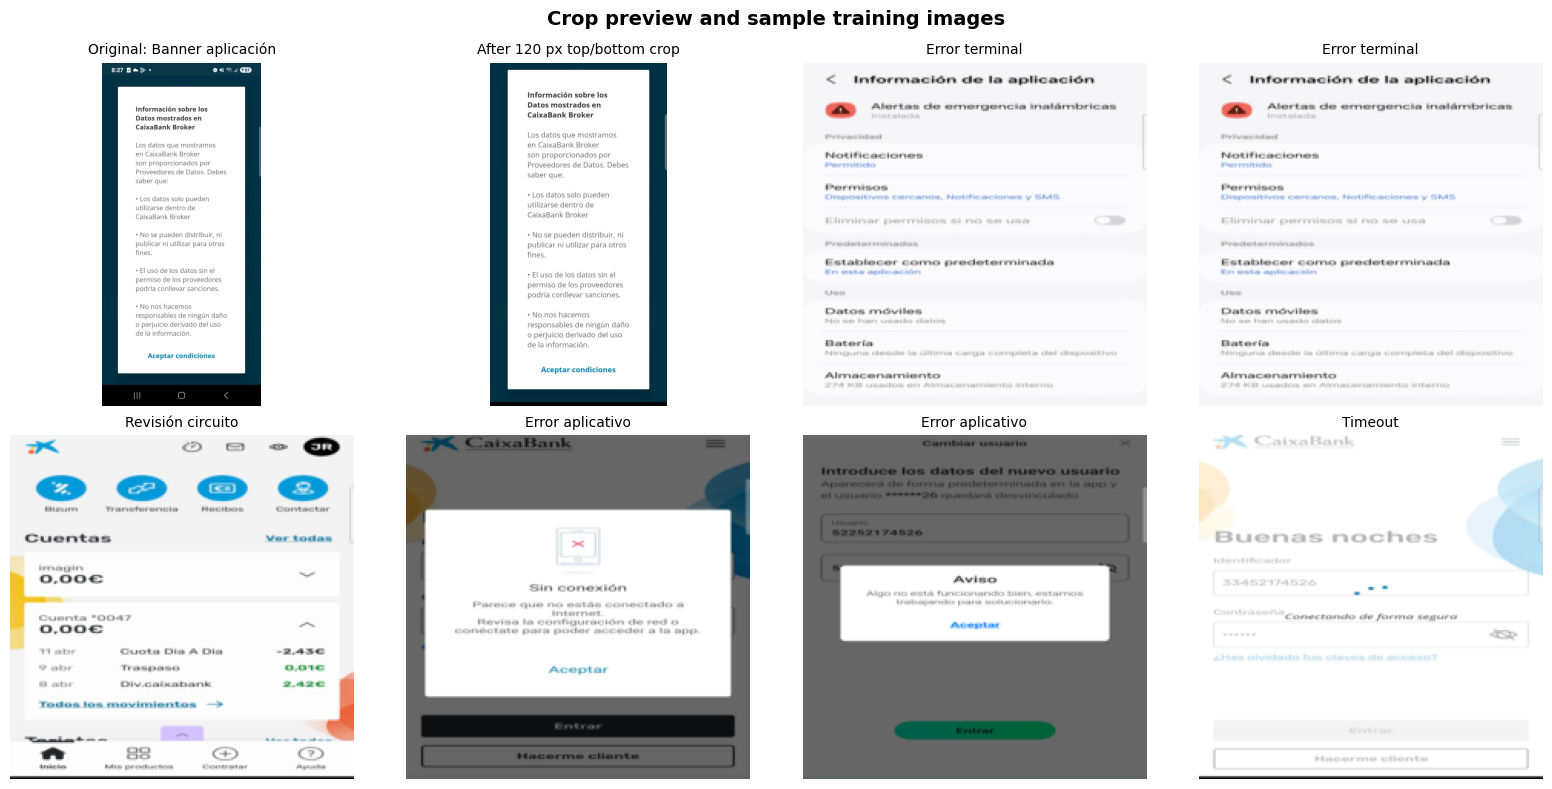

In [49]:
# Inverse normalization for visualization
inv_normalize = transforms.Compose([
    transforms.Normalize(mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
                          std=[1/0.229, 1/0.224, 1/0.225])
])

# Visualize sample images and the border crop effect
import PIL
sample_image = PIL.Image.open(sample_paths[0]).convert('RGB')
sample_label = sample_labels[0]
sample_cropped = safe_mobile_border_crop(sample_image)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

axes[0].imshow(sample_image)
axes[0].set_title(f"Original: {class_names[sample_label]}", fontsize=10)
axes[0].axis("off")

axes[1].imshow(sample_cropped)
axes[1].set_title(f"After {BORDER_CROP} px top/bottom crop", fontsize=10)
axes[1].axis("off")

images, labels = next(iter(train_loader))
for idx in range(2, min(8, len(images))):
    ax = axes[idx]
    img = inv_normalize(images[idx - 2]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(class_names[int(labels[idx - 2])], fontsize=10)
    ax.axis("off")

plt.suptitle("Crop preview and sample training images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Build Custom CNN Model from Scratch

In [10]:
# Define a custom CNN architecture trained from scratch
class CustomCNN(nn.Module):
    def __init__(self, num_classes=8):
        super(CustomCNN, self).__init__()
        
        # Block 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 224 -> 112
            nn.Dropout(0.25),
        )
        
        # Block 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 112 -> 56
            nn.Dropout(0.25),
        )
        
        # Block 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 56 -> 28
            nn.Dropout(0.25),
        )
        
        # Block 4
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 28 -> 14
            nn.Dropout(0.25),
        )
        
        # Global Average Pooling
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Fully connected layers
        self.classifier = nn.Sequential(
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.global_avg_pool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Initialize model
model = CustomCNN(num_classes=num_classes)
model = model.to(device)

print("Custom CNN Model Architecture:")
print(model)

Custom CNN Model Architecture:
CustomCNN(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2

In [10]:
# Model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nAll parameters are trainable (no frozen layers)")


Total parameters: 1,273,896
Trainable parameters: 1,273,896

All parameters are trainable (no frozen layers)


In [11]:
# Configure a loss and optimizer that work with balanced sampling
criterion = nn.CrossEntropyLoss(label_smoothing=0.02)
optimizer = optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=2e-4,
 )

print("Loss and optimizer configured.")
print("Loss function: CrossEntropyLoss with mild label smoothing")
print("Optimizer: AdamW (lr=2e-4, weight_decay=2e-4)")
print("Balanced sampling: enabled via WeightedRandomSampler")

Loss and optimizer configured.
Loss function: CrossEntropyLoss with mild label smoothing
Optimizer: AdamW (lr=2e-4, weight_decay=2e-4)
Balanced sampling: enabled via WeightedRandomSampler


## 5. Train Model

In [12]:
# Training controls
EPOCHS = 45
PATIENCE = 10
LR_FACTOR = 0.4
LR_PATIENCE = 3
MIN_LR = 1e-7
CONFIDENCE_THRESHOLD = 0.7

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
    min_lr=MIN_LR,
 )

print("Training controls configured.")
print(f"Max epochs: {EPOCHS}")
print(f"Early stopping patience: {PATIENCE}")
print(f"Confidence threshold: {CONFIDENCE_THRESHOLD:.2f}")
print("The confidence threshold is only used to flag uncertain predictions.")
print("Training schedule: longer run with faster LR decay to fit the balanced sampler.")

Training controls configured.
Max epochs: 45
Early stopping patience: 10
Confidence threshold: 0.70
The confidence threshold is only used to flag uncertain predictions.
Training schedule: longer run with faster LR decay to fit the balanced sampler.


In [13]:
# Train the model with early stopping
history = {"accuracy": [], "val_accuracy": [], "loss": [], "val_loss": []}
best_val_loss = float("inf")
best_state = None
patience_counter = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss_sum += loss.item() * images.size(0)
        preds = torch.argmax(logits, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total

    # Validation phase
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)

            val_loss_sum += loss.item() * images.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    scheduler.step(val_loss)

    history["loss"].append(train_loss)
    history["accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Epoch {epoch + 1}/{EPOCHS} | "
            f"loss: {train_loss:.4f} | acc: {train_acc:.4f} | "
            f"val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}"
        )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch + 1}.")
            break

if best_state is not None:
    model.load_state_dict(best_state)
    print("Restored best model weights.")

Epoch 1/45 | loss: 1.5948 | acc: 0.4827 | val_loss: 1.8270 | val_acc: 0.3078
Epoch 5/45 | loss: 0.4694 | acc: 0.8941 | val_loss: 0.5589 | val_acc: 0.8501
Epoch 10/45 | loss: 0.3024 | acc: 0.9565 | val_loss: 0.4468 | val_acc: 0.9130
Epoch 15/45 | loss: 0.2424 | acc: 0.9725 | val_loss: 0.2326 | val_acc: 0.9737
Epoch 20/45 | loss: 0.2046 | acc: 0.9845 | val_loss: 0.8050 | val_acc: 0.6888
Epoch 25/45 | loss: 0.1813 | acc: 0.9920 | val_loss: 0.2058 | val_acc: 0.9863
Epoch 30/45 | loss: 0.1729 | acc: 0.9911 | val_loss: 0.3085 | val_acc: 0.9462
Epoch 35/45 | loss: 0.1647 | acc: 0.9946 | val_loss: 0.1813 | val_acc: 0.9863
Epoch 40/45 | loss: 0.1541 | acc: 0.9983 | val_loss: 0.1727 | val_acc: 0.9908
Epoch 45/45 | loss: 0.1589 | acc: 0.9948 | val_loss: 0.1759 | val_acc: 0.9908
Restored best model weights.


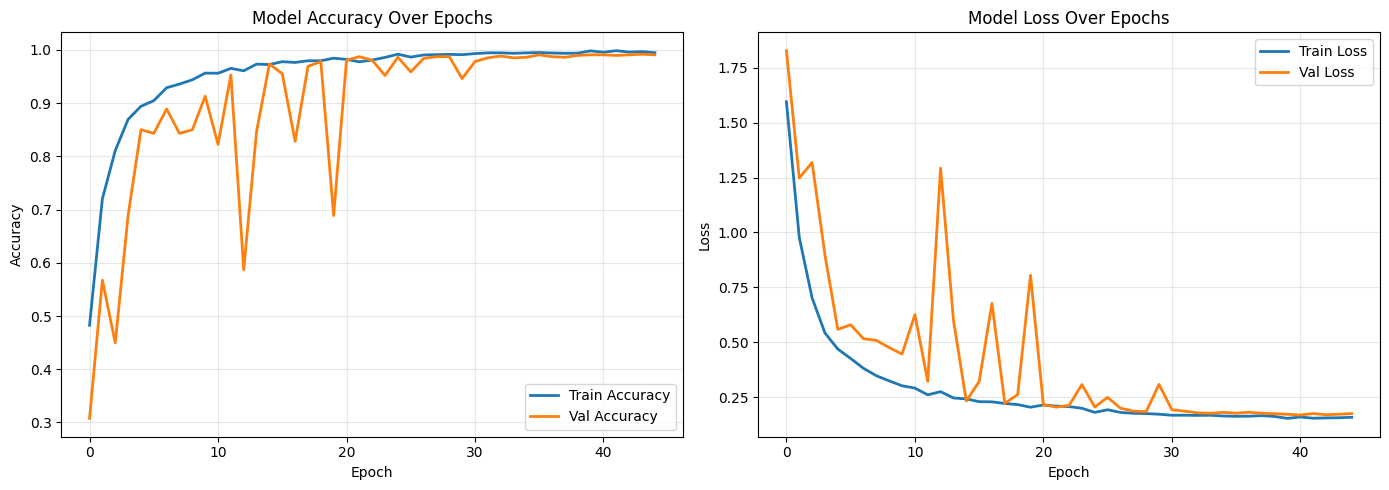


Training Summary:
Total epochs trained: 45
Best val accuracy: 0.9920
Best val loss: 0.1691
Final train accuracy: 0.9948
Final val accuracy: 0.9908


In [14]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Over Epochs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss Over Epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTraining Summary:")
print(f"Total epochs trained: {len(history['loss'])}")
print(f"Best val accuracy: {max(history['val_accuracy']):.4f}")
print(f"Best val loss: {min(history['val_loss']):.4f}")
print(f"Final train accuracy: {history['accuracy'][-1]:.4f}")
print(f"Final val accuracy: {history['val_accuracy'][-1]:.4f}")

## 6. Model Evaluation

In [15]:
# Evaluate final model on validation set
model.eval()

metrics = globals().get('validation_metrics', {})
final_val_accuracy = metrics.get('accuracy', float('nan'))
final_val_balanced_accuracy = metrics.get('balanced_accuracy', float('nan'))
final_val_macro_f1 = metrics.get('macro_f1', float('nan'))

print(f"Final Validation Accuracy: {final_val_accuracy:.4f}")
print(f"Final Validation Balanced Accuracy: {final_val_balanced_accuracy:.4f}")
print(f"Final Validation Macro F1: {final_val_macro_f1:.4f}")

Final Validation Accuracy: nan
Final Validation Balanced Accuracy: nan
Final Validation Macro F1: nan


In [16]:
# Get predictions for confusion matrix, classification report, and fairness metrics
y_pred = []
y_true = []
confidence_scores = []
val_paths = val_dataset.image_paths
failed_predictions = []
uncertain_predictions = []
path_offset = 0

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        batch_size = labels.size(0)
        batch_paths = val_paths[path_offset:path_offset + batch_size]
        path_offset += batch_size

        images = images.to(device)
        logits = model(images)
        probabilities = torch.softmax(logits, dim=1)
        max_probs, preds_tensor = torch.max(probabilities, dim=1)
        preds = preds_tensor.cpu().numpy()
        confidences = max_probs.cpu().numpy()

        y_pred.extend(preds.tolist())
        y_true.extend(labels.numpy().tolist())
        confidence_scores.extend(confidences.tolist())

        for path, true_idx, pred_idx, confidence in zip(batch_paths, labels.numpy().tolist(), preds.tolist(), confidences.tolist()):
            predicted_label = class_names[pred_idx] if confidence >= CONFIDENCE_THRESHOLD else "uncertain"
            record = {
                'path': path,
                'true_class': class_names[true_idx],
                'predicted_class': predicted_label,
                'confidence': confidence,
            }
            if confidence < CONFIDENCE_THRESHOLD:
                uncertain_predictions.append(record)
            elif true_idx != pred_idx:
                failed_predictions.append(record)

y_pred = np.array(y_pred)
y_true = np.array(y_true)
confidence_scores = np.array(confidence_scores)
failed_predictions_df = pd.DataFrame(failed_predictions)
uncertain_predictions_df = pd.DataFrame(uncertain_predictions)

validation_accuracy = accuracy_score(y_true, y_pred)
validation_balanced_accuracy = balanced_accuracy_score(y_true, y_pred)
validation_macro_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
validation_macro_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
validation_macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
validation_weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
validation_weighted_precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
validation_weighted_recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
uncertainty_rate = float(np.mean(confidence_scores < CONFIDENCE_THRESHOLD))
accepted_rate = 1.0 - uncertainty_rate

report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
per_class_metrics_df = pd.DataFrame(report_dict).T
per_class_metrics_df = per_class_metrics_df.loc[class_names, ['precision', 'recall', 'f1-score', 'support']]
per_class_metrics_df.index.name = 'class'

validation_f1_gap = float(per_class_metrics_df['f1-score'].max() - per_class_metrics_df['f1-score'].min())
validation_recall_gap = float(per_class_metrics_df['recall'].max() - per_class_metrics_df['recall'].min())
validation_worst_class_f1 = float(per_class_metrics_df['f1-score'].min())

validation_metrics = {
    'accuracy': float(validation_accuracy),
    'balanced_accuracy': float(validation_balanced_accuracy),
    'macro_precision': float(validation_macro_precision),
    'macro_recall': float(validation_macro_recall),
    'macro_f1': float(validation_macro_f1),
    'weighted_precision': float(validation_weighted_precision),
    'weighted_recall': float(validation_weighted_recall),
    'weighted_f1': float(validation_weighted_f1),
    'uncertainty_rate': float(uncertainty_rate),
    'accepted_rate': float(accepted_rate),
    'f1_gap': float(validation_f1_gap),
    'recall_gap': float(validation_recall_gap),
    'worst_class_f1': float(validation_worst_class_f1),
}

print(f"Predictions shape: {y_pred.shape}")
print(f"True labels shape: {y_true.shape}")
print(f"Validation Accuracy: {validation_accuracy:.4f}")
print(f"Validation Balanced Accuracy: {validation_balanced_accuracy:.4f}")
print(f"Validation Macro F1: {validation_macro_f1:.4f}")
print(f"Validation Weighted F1: {validation_weighted_f1:.4f}")
print(f"Validation Macro Precision: {validation_macro_precision:.4f}")
print(f"Validation Macro Recall: {validation_macro_recall:.4f}")
print(f"Uncertainty rate (< {CONFIDENCE_THRESHOLD:.2f}): {uncertainty_rate:.2%}")
print(f"Accepted predictions: {accepted_rate:.2%}")
print(f"F1 gap across classes: {validation_f1_gap:.4f}")
print(f"Recall gap across classes: {validation_recall_gap:.4f}")
print(f"Worst class F1: {validation_worst_class_f1:.4f}")
print(f"Misclassified validation samples above threshold: {len(failed_predictions_df)}")
print(f"Uncertain validation samples below threshold: {len(uncertain_predictions_df)}")

print("\nPer-class validation metrics:")
print(per_class_metrics_df.to_string())

if not failed_predictions_df.empty:
    print("\nFailed validation paths (confidence >= threshold but wrong):")
    print(failed_predictions_df[['path', 'true_class', 'predicted_class', 'confidence']].to_string(index=False))
else:
    print("\nNo misclassified validation samples with confidence above the threshold found.")

if not uncertain_predictions_df.empty:
    print("\nUncertain validation paths (confidence below threshold):")
    print(uncertain_predictions_df[['path', 'true_class', 'confidence']].to_string(index=False))
else:
    print("\nNo uncertain validation samples found.")

Predictions shape: (874,)
True labels shape: (874,)
Validation Accuracy: 0.9908
Validation Balanced Accuracy: 0.9702
Validation Macro F1: 0.9631
Validation Weighted F1: 0.9910
Validation Macro Precision: 0.9572
Validation Macro Recall: 0.9702
Uncertainty rate (< 0.70): 1.14%
Accepted predictions: 98.86%
F1 gap across classes: 0.2308
Recall gap across classes: 0.1667
Worst class F1: 0.7692
Misclassified validation samples above threshold: 4
Uncertain validation samples below threshold: 10

Per-class validation metrics:
                   precision    recall  f1-score  support
class                                                    
Banner aplicación   1.000000  1.000000  1.000000     27.0
Cierre aplicación   1.000000  1.000000  1.000000     54.0
Error aplicativo    1.000000  0.958333  0.978723     72.0
Error funcional     0.980952  1.000000  0.990385    103.0
Error terminal      1.000000  0.991525  0.995745    118.0
Indeterminado       0.714286  0.833333  0.769231      6.0
Revisión cir

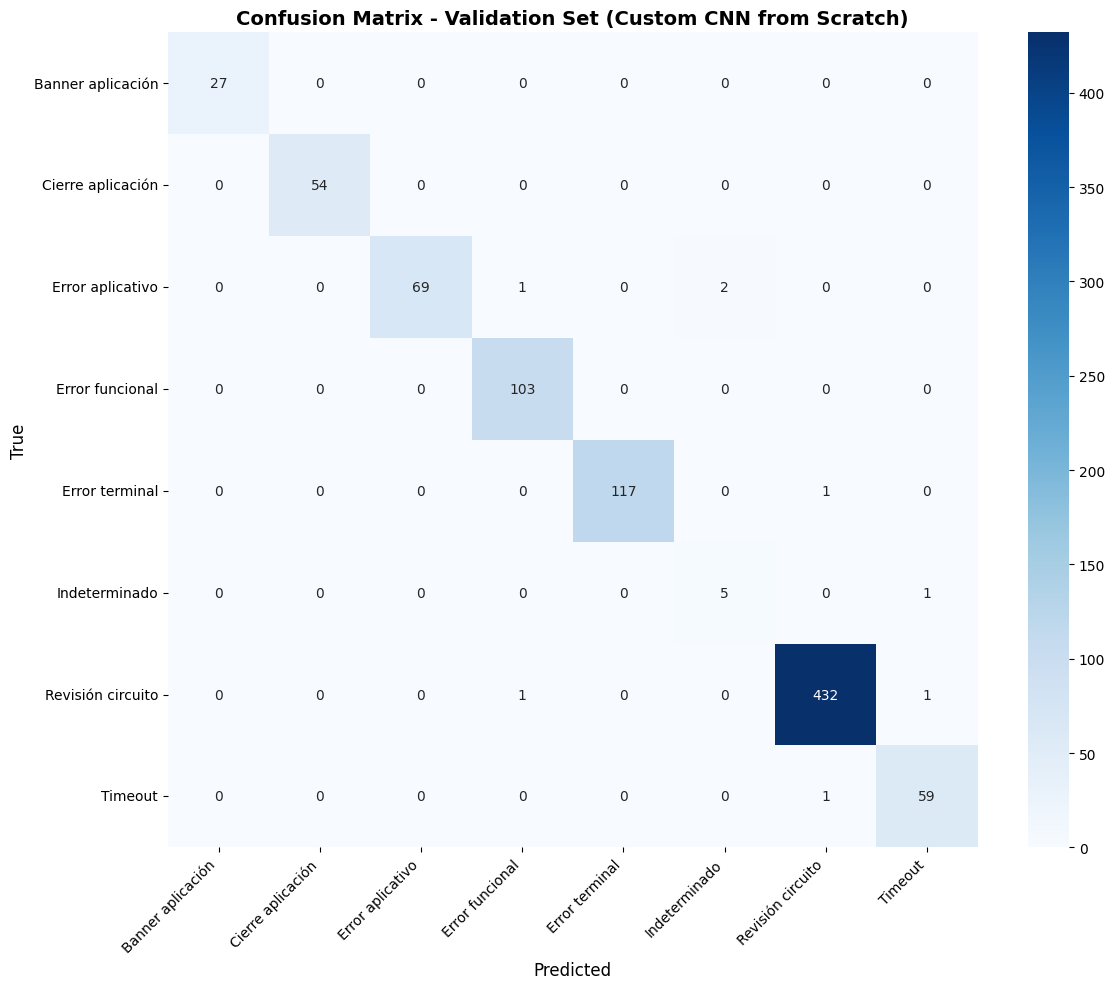

In [17]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Confusion Matrix - Validation Set (Custom CNN from Scratch)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
# Classification Report
print("Classification Report:")
print("=" * 70)
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

Classification Report:
                   precision    recall  f1-score   support

Banner aplicación       1.00      1.00      1.00        27
Cierre aplicación       1.00      1.00      1.00        54
 Error aplicativo       1.00      0.96      0.98        72
  Error funcional       0.98      1.00      0.99       103
   Error terminal       1.00      0.99      1.00       118
    Indeterminado       0.71      0.83      0.77         6
Revisión circuito       1.00      1.00      1.00       434
          Timeout       0.97      0.98      0.98        60

         accuracy                           0.99       874
        macro avg       0.96      0.97      0.96       874
     weighted avg       0.99      0.99      0.99       874



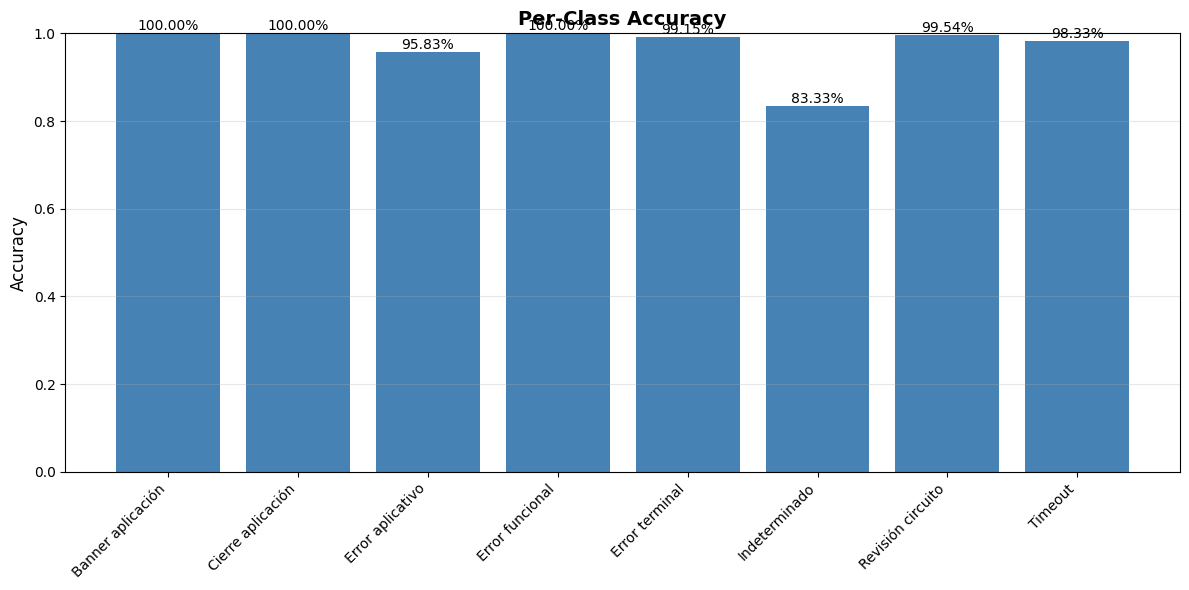


Per-Class Accuracy:
Banner aplicación: 100.00%
Cierre aplicación: 100.00%
Error aplicativo: 95.83%
Error funcional: 100.00%
Error terminal: 99.15%
Indeterminado: 83.33%
Revisión circuito: 99.54%
Timeout: 98.33%


In [19]:
# Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(class_names)), per_class_acc, color='steelblue')
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Per-Class Accuracy', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, acc in zip(bars, per_class_acc):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.2%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\nPer-Class Accuracy:")
for class_name, acc in zip(class_names, per_class_acc):
    print(f"{class_name}: {acc:.2%}")

## 7. Save Model

In [20]:
# Save model weights
models_dir = ROOT / 'TFM' / 'Models'
models_dir.mkdir(parents=True, exist_ok=True)

model_save_path = models_dir / 'cnn_full_DATA_45epochs.pth'
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

# Save class names for later inference
class_names_path = models_dir / 'class_names.json'
with open(class_names_path, 'w', encoding='utf-8') as f:
    json.dump(class_names, f, indent=4, ensure_ascii=False)
print(f"Class names saved to {class_names_path}")

Model saved to C:\Users\ibf\Desktop\TFM\Nou projecte\TFM\Models\cnn_full_DATA_45epochs.pth
Class names saved to C:\Users\ibf\Desktop\TFM\Nou projecte\TFM\Models\class_names.json


In [21]:
# Save training history
history_path = models_dir / 'custom_cnn_training_history.json'
history_to_save = {
    'accuracy': [float(acc) for acc in history['accuracy']],
    'val_accuracy': [float(acc) for acc in history['val_accuracy']],
    'loss': [float(loss) for loss in history['loss']],
    'val_loss': [float(loss) for loss in history['val_loss']],
}

with open(history_path, 'w', encoding='utf-8') as f:
    json.dump(history_to_save, f, indent=4, ensure_ascii=False)
print(f"Training history saved to {history_path}")

Training history saved to C:\Users\ibf\Desktop\TFM\Nou projecte\TFM\Models\custom_cnn_training_history.json


## 8. Model Inference Example

In [63]:
# Function for single image inference
def predict_image(image_path, model, transform, device, class_names, confidence_threshold=CONFIDENCE_THRESHOLD):
    from PIL import Image
    
    model.eval()
    image = Image.open(image_path).convert('RGB')
    
    # Apply transforms
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # Predict
    with torch.no_grad():
        logits = model(image_tensor)
        probabilities = torch.softmax(logits, dim=1)
        max_probability, predicted_class = torch.max(probabilities, dim=1)
        confidence = max_probability.item()
        predicted_class = predicted_class.item()
    
    if confidence < confidence_threshold:
        predicted_label = "uncertain"
    else:
        predicted_label = class_names[predicted_class]
    
    return {
        'predicted_class': predicted_label,
        'confidence': confidence,
        'all_probabilities': {class_names[i]: prob.item() for i, prob in enumerate(probabilities[0])}
    }

print("Inference function defined. Ready to predict on new images.")

Inference function defined. Ready to predict on new images.


In [64]:
# Example inference on a validation image
from PIL import Image

# Get first image from validation set
val_image, val_label = val_dataset[0]

# Get prediction
model.eval()
with torch.no_grad():
    val_image_tensor = val_image.unsqueeze(0).to(device)
    logits = model(val_image_tensor)
    probabilities = torch.softmax(logits, dim=1)
    predicted_class_idx = torch.argmax(probabilities, dim=1).item()

predicted_class = class_names[predicted_class_idx]
true_class = class_names[val_label]
confidence = probabilities[0][predicted_class_idx].item()

print(f"True class: {true_class}")
print(f"Predicted class: {predicted_class}")
print(f"Confidence: {confidence:.4f}")
print(f"\nAll class probabilities:")
for i, class_name in enumerate(class_names):
    print(f"  {class_name}: {probabilities[0][i].item():.4f}")

True class: Revisión circuito
Predicted class: Revisión circuito
Confidence: 0.8073

All class probabilities:
  Banner aplicación: 0.0361
  Cierre aplicación: 0.0213
  Error aplicativo: 0.0273
  Error funcional: 0.0198
  Error terminal: 0.0120
  Indeterminado: 0.0597
  Revisión circuito: 0.8073
  Timeout: 0.0164


## 9. Model Summary and Comparison

In [65]:
# Create a summary report
print("\n" + "="*70)
print("CUSTOM CNN FROM SCRATCH - MODEL SUMMARY")
print("="*70)

metrics = globals().get('validation_metrics', {})
per_class_df = globals().get('per_class_metrics_df')
history = globals().get('history', {'loss': []})

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel Configuration:")
print(f"  - Architecture: Custom 4-layer CNN")
print(f"  - Total Parameters: {total_params:,}")
print(f"  - Trainable Parameters: {trainable_params:,}")
print(f"  - Training Strategy: From scratch (no pre-trained weights)")

print(f"\nData Configuration:")
print(f"  - Image Size: {IMAGE_SIZE}")
print(f"  - Batch Size: {BATCH_SIZE}")
print(f"  - Training Samples: {len(train_dataset)}")
print(f"  - Validation Samples: {len(val_dataset)}")
print(f"  - Number of Classes: {num_classes}")
print(f"  - Classes: {', '.join(class_names)}")

print(f"\nTraining Configuration:")
print(f"  - Optimizer: AdamW (lr=3e-4)")
print(f"  - Loss Function: Weighted CrossEntropyLoss with label smoothing")
print(f"  - Max Epochs: {EPOCHS}")
print(f"  - Early Stopping Patience: {PATIENCE}")
print(f"  - Confidence Threshold: {CONFIDENCE_THRESHOLD:.2f}")
print(f"  - Epochs Trained: {len(history['loss'])}")
print("  - Oversampling: disabled")

print(f"\nFairness-Oriented Validation Metrics:")
print(f"  - Accuracy: {metrics.get('accuracy', float('nan')):.4f}")
print(f"  - Balanced Accuracy: {metrics.get('balanced_accuracy', float('nan')):.4f}")
print(f"  - Macro Precision: {metrics.get('macro_precision', float('nan')):.4f}")
print(f"  - Macro Recall: {metrics.get('macro_recall', float('nan')):.4f}")
print(f"  - Macro F1: {metrics.get('macro_f1', float('nan')):.4f}")
print(f"  - Weighted F1: {metrics.get('weighted_f1', float('nan')):.4f}")
print(f"  - Worst Class F1: {metrics.get('worst_class_f1', float('nan')):.4f}")
print(f"  - F1 Gap: {metrics.get('f1_gap', float('nan')):.4f}")
print(f"  - Recall Gap: {metrics.get('recall_gap', float('nan')):.4f}")
print(f"  - Uncertainty Rate: {metrics.get('uncertainty_rate', float('nan')):.2%}")

print(f"\nPer-Class Performance (on validation set):")
if per_class_df is not None:
    for class_name in class_names:
        if class_name in per_class_df.index:
            print(f"  - {class_name}: F1={per_class_df.loc[class_name, 'f1-score']:.2%}, Recall={per_class_df.loc[class_name, 'recall']:.2%}")
else:
    print("  - Per-class metrics unavailable until the validation cell runs.")

print("\n" + "="*70)


CUSTOM CNN FROM SCRATCH - MODEL SUMMARY

Model Configuration:
  - Architecture: Custom 4-layer CNN
  - Total Parameters: 1,273,896
  - Trainable Parameters: 1,273,896
  - Training Strategy: From scratch (no pre-trained weights)

Data Configuration:
  - Image Size: (224, 224)
  - Batch Size: 32
  - Training Samples: 2211
  - Validation Samples: 553
  - Number of Classes: 8
  - Classes: Banner aplicación, Cierre aplicación, Error aplicativo, Error funcional, Error terminal, Indeterminado, Revisión circuito, Timeout

Training Configuration:
  - Optimizer: AdamW (lr=3e-4)
  - Loss Function: Weighted CrossEntropyLoss with label smoothing
  - Max Epochs: 30
  - Early Stopping Patience: 7
  - Confidence Threshold: 0.70
  - Epochs Trained: 30
  - Oversampling: disabled

Fairness-Oriented Validation Metrics:
  - Accuracy: 0.9928
  - Balanced Accuracy: 0.9916
  - Macro Precision: 0.9960
  - Macro Recall: 0.9916
  - Macro F1: 0.9938
  - Weighted F1: 0.9928
  - Worst Class F1: 0.9815
  - F1 Gap: 